<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/03_rnn_and_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, time, math, random
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# seed information
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # deterministic can slow training, but makes runs reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


Mini Dataset Card (UCI HAR Inertial Signals)

Motivation / Intended use: Prototype on-device activity recognition from smartphone accelerometer + gyroscope windows, with emphasis on subject generalization and inference latency.

Target definition: 6-class activity label per window (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING).

Data source & license: UCI Human Activity Recognition (HAR) Dataset (windowed IMU signals). Use is for research/education; cite the UCI repo and original paper in your submission.

Signals: Windowed time series at 50 Hz, window length 2.56 s = 128 timesteps. Channels: 9 inertial signals (3 body accel, 3 gyro, 3 total accel).

Known constraints: Must use sequential windows (RNN meaningful). Must use subject-disjoint split (no subject overlap between train/val and test).

Limitations / risks: Limited population and recording protocol; potential domain shift across devices/placement; labels may not cover real-world activity variation; misclassifications can impact user experience/safety in downstream applications.

Path Checking --> Ensure this is valid

In [2]:
BASE = r"/content/UCI_Dataset"

assert os.path.isdir(BASE), f"BASE path not found: {BASE}"

print("BASE:", BASE)
print("Train dir exists:", os.path.isdir(os.path.join(BASE, "train")))
print("Test dir exists:", os.path.isdir(os.path.join(BASE, "test")))


BASE: /content/UCI_Dataset
Train dir exists: True
Test dir exists: True


Next we load the inertial signals (9 different txt files in each test/train folder). Stack all into one array (N, 128, 9)

In [3]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

LABEL_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

def load_split(split: str):
    assert split in ["train", "test"]
    inertial_dir = os.path.join(BASE, split, "Inertial Signals")

    X_list = []
    for sig in SIGNALS:
        fp = os.path.join(inertial_dir, f"{sig}_{split}.txt")
        if not os.path.isfile(fp):
            raise FileNotFoundError(f"Missing file: {fp}")
        arr = np.loadtxt(fp)            # (N, 128)
        X_list.append(arr[..., None])   # (N, 128, 1)

    X = np.concatenate(X_list, axis=2)  # (N, 128, 9)

    y = np.loadtxt(os.path.join(BASE, split, f"y_{split}.txt")).astype(int) - 1  # 0..5
    subj = np.loadtxt(os.path.join(BASE, split, f"subject_{split}.txt")).astype(int)

    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

X_train_all, y_train_all, subj_train_all = load_split("train")
X_test,      y_test,      subj_test      = load_split("test")

print("Train:", X_train_all.shape, y_train_all.shape, subj_train_all.shape)
print("Test :", X_test.shape, y_test.shape, subj_test.shape)


Train: (7352, 128, 9) (7352,) (7352,)
Test : (2947, 128, 9) (2947,) (2947,)


Confirmation that the data is loaded correctly by checking:
- (N,T,C) shape of array
- Print label distribution
- Catch NaN values

In [4]:
# 1) Confirm shapes (N, T, C)
Ntr, T, C = X_train_all.shape
Nte = X_test.shape[0]
print(f"Train shape: (N,T,C)=({Ntr},{T},{C})")
print(f"Test  shape: (N,T,C)=({Nte},{T},{C})")

# 2) Label distribution
print("Train label distribution:")
print(pd.Series(y_train_all).value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))

# 3) NaN/inf checks
print("\nFinite train:", np.isfinite(X_train_all).all())
print("Finite test :", np.isfinite(X_test).all())

assert np.isfinite(X_train_all).all(), "Found NaN/inf in training data"
assert np.isfinite(X_test).all(), "Found NaN/inf in test data"


Train shape: (N,T,C)=(7352,128,9)
Test  shape: (N,T,C)=(2947,128,9)
Train label distribution:
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
SITTING               1286
STANDING              1374
LAYING                1407
Name: count, dtype: int64

Test label distribution:
WALKING               496
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
SITTING               491
STANDING              532
LAYING                537
Name: count, dtype: int64

Finite train: True
Finite test : True


Leakage Check, ensures that there is no overlap in subjects between the train and test subjects.

In [5]:
train_subjects = set(subj_train_all.tolist())
test_subjects  = set(subj_test.tolist())

overlap = train_subjects.intersection(test_subjects)
print("Subject overlap size (must be 0):", len(overlap))
# Prove it explicitly:
print("Overlap set:", overlap)

assert len(overlap) == 0, "Leakage detected: train/test share subjects!"


Subject overlap size (must be 0): 0
Overlap set: set()


Conduct the disjoint split with the following information
- train-subjects
- validation-subjects
- train-subjects don't overlap with validation-subjects (leakage)
- neither overlaps test subjects

In [6]:
def subject_disjoint_train_val_split(X, y, subj, val_frac=0.2, seed=42):
    set_global_seed(seed)
    uniq = np.array(sorted(set(subj.tolist())))
    rng = np.random.default_rng(seed)
    rng.shuffle(uniq)

    n_val = max(1, int(len(uniq) * val_frac))
    val_subjects = set(uniq[:n_val].tolist())
    tr_subjects  = set(uniq[n_val:].tolist())

    tr_mask  = np.isin(subj, list(tr_subjects))
    val_mask = np.isin(subj, list(val_subjects))

    X_tr, y_tr, subj_tr = X[tr_mask], y[tr_mask], subj[tr_mask]
    X_val, y_val, subj_val = X[val_mask], y[val_mask], subj[val_mask]

    # Safety checks
    assert len(set(subj_tr.tolist()).intersection(set(subj_val.tolist()))) == 0
    assert len(set(subj_tr.tolist()).intersection(set(subj_test.tolist()))) == 0
    assert len(set(subj_val.tolist()).intersection(set(subj_test.tolist()))) == 0

    return (X_tr, y_tr, subj_tr), (X_val, y_val, subj_val), (tr_subjects, val_subjects)

SEED = 42
(X_tr, y_tr, subj_tr), (X_val, y_val, subj_val), (tr_subj_set, val_subj_set) = subject_disjoint_train_val_split(
    X_train_all, y_train_all, subj_train_all, val_frac=0.2, seed=SEED
)

print("Train windows:", X_tr.shape, "Val windows:", X_val.shape)
print("Train subjects:", len(tr_subj_set), "Val subjects:", len(val_subj_set))
print("Train/Val subject overlap:", len(tr_subj_set.intersection(val_subj_set)))


Train windows: (5800, 128, 9) Val windows: (1552, 128, 9)
Train subjects: 17 Val subjects: 4
Train/Val subject overlap: 0


Baseline 0: trivial majority-class predictor


In [7]:
majority = np.bincount(y_tr).argmax()
yhat_val = np.full_like(y_val, majority)

acc = accuracy_score(y_val, yhat_val)
mf1 = f1_score(y_val, yhat_val, average="macro")

print("Baseline0 majority class:", majority, LABEL_NAMES[majority])
print("Val accuracy:", acc)
print("Val macro-F1:", mf1)


Baseline0 majority class: 5 LAYING
Val accuracy: 0.18685567010309279
Val macro-F1: 0.05247918928700687


Build the Pytorch dataset + dataloaders
- Flatten for MLP
- Sequence Windows for GRU

In [8]:
class HARWindowDataset(Dataset):
    def __init__(self, X, y, flatten=False):
        self.X = torch.from_numpy(X)  # (N, T, C)
        self.y = torch.from_numpy(y)
        self.flatten = flatten

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (T, C)
        if self.flatten:
            x = x.reshape(-1)  # (T*C,)
        return x, self.y[idx]

def make_loaders(Xtr, ytr, Xva, yva, batch_size=128, flatten=False, num_workers=0):
    tr_ds = HARWindowDataset(Xtr, ytr, flatten=flatten)
    va_ds = HARWindowDataset(Xva, yva, flatten=flatten)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, drop_last=False)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
    return tr_dl, va_dl

BATCH_SIZE = 128
tr_dl_mlp, va_dl_mlp = make_loaders(X_tr, y_tr, X_val, y_val, batch_size=BATCH_SIZE, flatten=True)
tr_dl_seq, va_dl_seq = make_loaders(X_tr, y_tr, X_val, y_val, batch_size=BATCH_SIZE, flatten=False)


Definitions of MLP and GRU Models
- MLP: Treat each window as a flat vector (ignore time order)
- GRU: Read the window as a sequence and learns temporal pattern

In [9]:
class MLPBaseline(nn.Module):
    def __init__(self, in_dim=128*9, num_classes=6, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x):
        return self.net(x)

class GRUModel(nn.Module):
    def __init__(self, in_ch=9, hidden=128, num_layers=1, num_classes=6, dropout=0.2, bidir=False):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_ch,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
            bidirectional=bidir
        )
        out_dim = hidden * (2 if bidir else 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, T, C)
        out, _ = self.gru(x)
        last = out[:, -1, :]      # last timestep
        return self.head(last)


Training Utility class and functions

In [10]:
@dataclass
class RunConfig:
    run_name: str
    model_type: str
    seed: int
    lr: float
    weight_decay: float
    dropout: float
    batch_size: int
    max_epochs: int
    patience: int
    grad_clip: float
    scheduler: str  # "none" or "cosine" or "step"
    hidden: int = 256
    num_layers: int = 1
    bidir: bool = False

def evaluate(model, dl):
    model.eval()
    ys, yh = [], []
    losses = []
    with torch.no_grad():
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            losses.append(loss.item())
            pred = logits.argmax(dim=1)
            ys.append(y.cpu().numpy())
            yh.append(pred.cpu().numpy())
    ys = np.concatenate(ys)
    yh = np.concatenate(yh)
    return {
        "loss": float(np.mean(losses)),
        "acc": float(accuracy_score(ys, yh)),
        "macro_f1": float(f1_score(ys, yh, average="macro")),
        "y_true": ys,
        "y_pred": yh,
    }

def train_one_run(cfg: RunConfig, tr_dl, va_dl, model, out_dir="artifacts"):
    os.makedirs(out_dir, exist_ok=True)
    set_global_seed(cfg.seed)
    model = model.to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    if cfg.scheduler == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.max_epochs)
    elif cfg.scheduler == "step":
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=max(1, cfg.max_epochs//3), gamma=0.5)
    else:
        sched = None

    best_val = -1e9
    best_path = os.path.join(out_dir, f"{cfg.run_name}_best.pt")
    bad_epochs = 0

    history = []
    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        tr_losses = []
        for x, y in tr_dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite loss encountered (NaN/inf).")

            loss.backward()
            if cfg.grad_clip and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            tr_losses.append(loss.item())

        if sched is not None:
            sched.step()

        tr_eval = {"loss": float(np.mean(tr_losses))}
        va_eval = evaluate(model, va_dl)

        history.append({
            "epoch": epoch,
            "train_loss": tr_eval["loss"],
            "val_loss": va_eval["loss"],
            "val_acc": va_eval["acc"],
            "val_macro_f1": va_eval["macro_f1"],
            "lr": opt.param_groups[0]["lr"]
        })

        score = va_eval["macro_f1"]  # choose macro-F1 as validation selector
        if score > best_val:
            best_val = score
            bad_epochs = 0
            torch.save({
                "model_state": model.state_dict(),
                "config": asdict(cfg),
                "val_macro_f1": best_val,
                "timestamp": datetime.now().isoformat(),
            }, best_path)
        else:
            bad_epochs += 1

        if bad_epochs >= cfg.patience:
            break

    # load best checkpoint for final val metrics
    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    final_val = evaluate(model, va_dl)

    return best_path, pd.DataFrame(history), final_val


Functions to add information to CSV output log, generate F1 table, create confusion matrix.

In [11]:
LOG_PATH = "experiment_log.csv"

def append_log_row(row: dict, path=LOG_PATH):
    df = pd.DataFrame([row])
    if os.path.isfile(path):
        df.to_csv(path, mode="a", header=False, index=False)
    else:
        df.to_csv(path, index=False)

def per_class_f1_table(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
    rows = []
    for i, name in enumerate(LABEL_NAMES):
        rows.append({
            "class": name,
            "precision": report[name]["precision"],
            "recall": report[name]["recall"],
            "f1": report[name]["f1-score"],
            "support": report[name]["support"],
        })
    return pd.DataFrame(rows)

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.xticks(range(len(LABEL_NAMES)), LABEL_NAMES, rotation=45, ha="right")
    plt.yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Training for MLP baseline

In [12]:
cfg_mlp = RunConfig(
    run_name="mlp_baseline_v1",
    model_type="MLP",
    seed=42,
    lr=1e-3,
    weight_decay=1e-4,
    dropout=0.2,
    batch_size=BATCH_SIZE,
    max_epochs=50,
    patience=8,
    grad_clip=1.0,
    scheduler="none",
    hidden=256
)

mlp = MLPBaseline(in_dim=128*9, num_classes=6, hidden=cfg_mlp.hidden, dropout=cfg_mlp.dropout)

best_path, hist_df, val_metrics = train_one_run(cfg_mlp, tr_dl_mlp, va_dl_mlp, mlp, out_dir="artifacts")

print("Best checkpoint:", best_path)
print("Final Val:", {k: val_metrics[k] for k in ["loss","acc","macro_f1"]})

display(hist_df.tail(10))


Best checkpoint: artifacts/mlp_baseline_v1_best.pt
Final Val: {'loss': 0.22368558782797593, 'acc': 0.9143041237113402, 'macro_f1': 0.9112095842553991}


,epoch,train_loss,val_loss,val_acc,val_macro_f1,lr
3,4,0.195602,0.319053,0.865335,0.860060,0.001
4,5,0.159020,0.223686,0.914304,0.911210,0.001
5,6,0.137526,0.277299,0.893041,0.890756,0.001
6,7,0.131697,0.248575,0.885954,0.885391,0.001
7,8,0.131354,0.275467,0.896263,0.895049,0.001
8,9,0.119096,0.286687,0.898840,0.897457,0.001
9,10,0.110905,0.313780,0.887242,0.884730,0.001
10,11,0.109695,0.320124,0.885309,0.883639,0.001
11,12,0.105177,0.308340,0.887887,0.887432,0.001
12,13,0.104738,0.365404,0.885309,0.882479,0.001


Output cell for MLP training

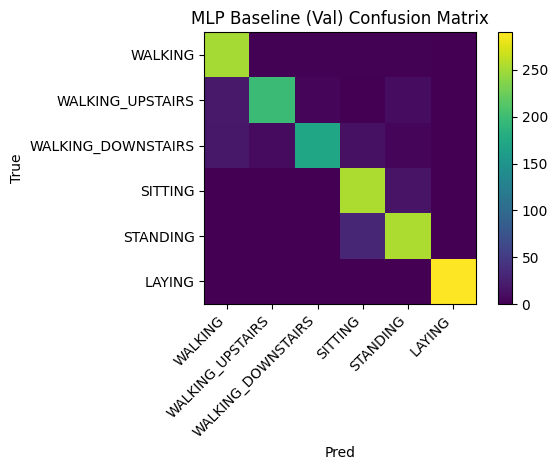

,class,precision,recall,f1,support
0,WALKING,0.865517,0.969112,0.914390,259.0
1,WALKING_UPSTAIRS,0.951923,0.849785,0.897959,233.0
2,WALKING_DOWNSTAIRS,0.960894,0.796296,0.870886,216.0
3,SITTING,0.846667,0.944238,0.892794,269.0
4,STANDING,0.891228,0.891228,0.891228,285.0
5,LAYING,1.000000,1.000000,1.000000,290.0


Val accuracy: 0.9143041237113402
Val macro-F1: 0.9112095842553991


In [13]:
y_true = val_metrics["y_true"]
y_pred = val_metrics["y_pred"]

plot_confusion(y_true, y_pred, title="MLP Baseline (Val) Confusion Matrix")

tbl = per_class_f1_table(y_true, y_pred)
display(tbl)

print("Val accuracy:", accuracy_score(y_true, y_pred))
print("Val macro-F1:", f1_score(y_true, y_pred, average="macro"))


Append MLP run data to CSV

In [ ]:
row = {
    "run": cfg_mlp.run_name,
    "model": cfg_mlp.model_type,
    "params": str(asdict(cfg_mlp)),
    "seed": cfg_mlp.seed,
    "val_acc": val_metrics["acc"],
    "val_macro_f1": val_metrics["macro_f1"],
    "timestamp": datetime.now().isoformat(),
    "best_ckpt": best_path,
    "eval_source": "val_subjects_only"
}
append_log_row(row)

print("Wrote log row to", LOG_PATH)
print(pd.read_csv(LOG_PATH).tail(5))


Wrote log row to experiment_log.csv
               run model                                             params  \
0  mlp_baseline_v1   MLP  {'run_name': 'mlp_baseline_v1', 'model_type': ...   

   seed   val_acc  val_macro_f1                   timestamp  \
0    42  0.914304       0.91121  2026-02-19T15:43:26.796795   

                           best_ckpt        eval_source  
0  artifacts/mlp_baseline_v1_best.pt  val_subjects_only  


Training for GRU baseline

In [14]:
cfg_gru = RunConfig(
    run_name="gru_v1",
    model_type="GRU",
    seed=42,
    lr=1e-3,
    weight_decay=1e-4,
    dropout=0.2,
    batch_size=BATCH_SIZE,
    max_epochs=50,
    patience=8,
    grad_clip=1.0,
    scheduler="none",
    hidden=128,
    num_layers=1,
    bidir=False
)

gru = GRUModel(in_ch=9, hidden=cfg_gru.hidden, num_layers=cfg_gru.num_layers,
               num_classes=6, dropout=cfg_gru.dropout, bidir=cfg_gru.bidir)

best_path_gru, hist_df_gru, val_metrics_gru = train_one_run(cfg_gru, tr_dl_seq, va_dl_seq, gru, out_dir="artifacts")

print("Best checkpoint:", best_path_gru)
print("Final Val:", {k: val_metrics_gru[k] for k in ["loss","acc","macro_f1"]})
display(hist_df_gru.tail(10))


Best checkpoint: artifacts/gru_v1_best.pt
Final Val: {'loss': 0.15746086792877087, 'acc': 0.9536082474226805, 'macro_f1': 0.9542169349474573}


,epoch,train_loss,val_loss,val_acc,val_macro_f1,lr
23,24,0.142827,0.243727,0.925258,0.925721,0.001
24,25,0.151582,0.157461,0.953608,0.954217,0.001
25,26,0.139726,0.215358,0.913015,0.913755,0.001
26,27,0.136015,0.290185,0.921392,0.921376,0.001
27,28,0.140823,0.201048,0.925902,0.926542,0.001
28,29,0.129310,0.178273,0.947165,0.947593,0.001
29,30,0.136854,0.218144,0.922036,0.922724,0.001
30,31,0.122606,0.203893,0.944588,0.945651,0.001
31,32,0.136530,0.234667,0.938789,0.939259,0.001
32,33,0.137001,0.243304,0.926546,0.926937,0.001


Output cell for GRU training and write to CSV

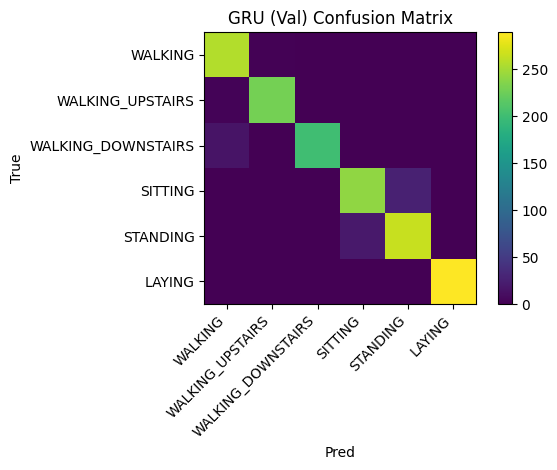

,class,precision,recall,f1,support
0,WALKING,0.934307,0.988417,0.960600,259.0
1,WALKING_UPSTAIRS,0.987069,0.982833,0.984946,233.0
2,WALKING_DOWNSTAIRS,0.990099,0.925926,0.956938,216.0
3,SITTING,0.919847,0.895911,0.907721,269.0
4,STANDING,0.907534,0.929825,0.918544,285.0
5,LAYING,0.996552,0.996552,0.996552,290.0


      run model                                             params  seed  \
0  gru_v1   GRU  {'run_name': 'gru_v1', 'model_type': 'GRU', 's...    42   

    val_acc  val_macro_f1                   timestamp  \
0  0.953608      0.954217  2026-03-12T14:29:36.517745   

                  best_ckpt        eval_source  
0  artifacts/gru_v1_best.pt  val_subjects_only  


In [15]:
y_true = val_metrics_gru["y_true"]
y_pred = val_metrics_gru["y_pred"]

plot_confusion(y_true, y_pred, title="GRU (Val) Confusion Matrix")
tbl_gru = per_class_f1_table(y_true, y_pred)
display(tbl_gru)

row = {
    "run": cfg_gru.run_name,
    "model": cfg_gru.model_type,
    "params": str(asdict(cfg_gru)),
    "seed": cfg_gru.seed,
    "val_acc": val_metrics_gru["acc"],
    "val_macro_f1": val_metrics_gru["macro_f1"],
    "timestamp": datetime.now().isoformat(),
    "best_ckpt": best_path_gru,
    "eval_source": "val_subjects_only"
}
append_log_row(row)

print(pd.read_csv(LOG_PATH).tail(5))


Model Selection Rule (Validation Discipline)

We select the final model only using validation performance (macro-F1). The test split remains untouched during tuning. After selecting the best run, we evaluate once on the test set for a final estimate of subject-generalization.

Selected: GRU
Test: {'loss': 0.27390435345781344, 'acc': 0.9043094672548354, 'macro_f1': 0.9057362255758417}


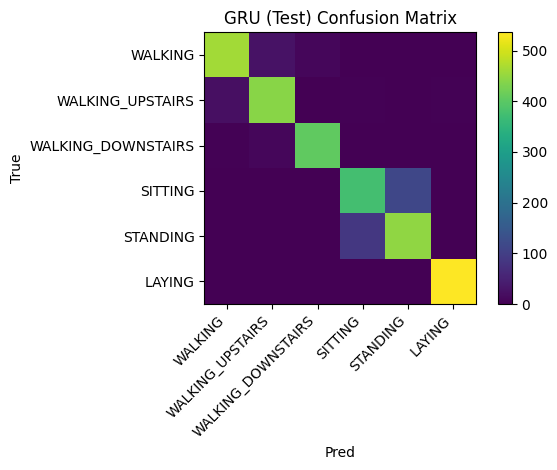

,class,precision,recall,f1,support
0,WALKING,0.946612,0.929435,0.937945,496.0
1,WALKING_UPSTAIRS,0.922432,0.934183,0.928270,471.0
2,WALKING_DOWNSTAIRS,0.973621,0.966667,0.970131,420.0
3,SITTING,0.808602,0.765784,0.786611,491.0
4,STANDING,0.795009,0.838346,0.816102,532.0
5,LAYING,0.992593,0.998138,0.995357,537.0


In [16]:
# Pick best based on your validation results (macro-F1)
best_choice = "GRU" if val_metrics_gru["macro_f1"] >= val_metrics["macro_f1"] else "MLP"
print("Selected:", best_choice)

# Build matching model and loader for test
if best_choice == "MLP":
    chosen_cfg = cfg_mlp
    chosen_ckpt = best_path
    test_dl = DataLoader(HARWindowDataset(X_test, y_test, flatten=True), batch_size=256, shuffle=False)
    model = MLPBaseline(in_dim=128*9, num_classes=6, hidden=chosen_cfg.hidden, dropout=chosen_cfg.dropout)
else:
    chosen_cfg = cfg_gru
    chosen_ckpt = best_path_gru
    test_dl = DataLoader(HARWindowDataset(X_test, y_test, flatten=False), batch_size=256, shuffle=False)
    model = GRUModel(in_ch=9, hidden=chosen_cfg.hidden, num_layers=chosen_cfg.num_layers,
                     num_classes=6, dropout=chosen_cfg.dropout, bidir=chosen_cfg.bidir)

ckpt = torch.load(chosen_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.to(DEVICE)

test_metrics = evaluate(model, test_dl)
print("Test:", {k: test_metrics[k] for k in ["loss","acc","macro_f1"]})

plot_confusion(test_metrics["y_true"], test_metrics["y_pred"], title=f"{best_choice} (Test) Confusion Matrix")
display(per_class_f1_table(test_metrics["y_true"], test_metrics["y_pred"]))


Creates a new check point from the previously determined checkpoint with the best model, its weights, hyperpameters and labels

In [17]:
DEPLOY_CKPT = "artifacts/deploy_model.pt"
torch.save({
    "model_state": model.state_dict(),
    "model_type": best_choice,
    "config": asdict(chosen_cfg),
    "label_names": LABEL_NAMES,
    "timestamp": datetime.now().isoformat(),
}, DEPLOY_CKPT)

print("Saved deploy checkpoint:", DEPLOY_CKPT)


Saved deploy checkpoint: artifacts/deploy_model.pt


Inference Function

In [20]:
# Force CPU
DEVICE = "cpu"
print("Device:", DEVICE)

def load_deploy_model(path=DEPLOY_CKPT):
    payload = torch.load(path, map_location=DEVICE)
    cfg = payload["config"]
    model_type = payload["model_type"]

    if model_type == "MLP":
        m = MLPBaseline(
            in_dim=128*9,
            num_classes=6,
            hidden=cfg["hidden"],
            dropout=cfg["dropout"]
        )
        flatten = True
    else:
        m = GRUModel(
            in_ch=9,
            hidden=cfg["hidden"],
            num_layers=cfg["num_layers"],
            num_classes=6,
            dropout=cfg["dropout"],
            bidir=cfg["bidir"]
        )
        flatten = False

    m.load_state_dict(payload["model_state"])
    m.to(DEVICE).eval()
    return m, flatten, payload["label_names"]

deploy_model, deploy_flatten, deploy_labels = load_deploy_model()

def predict_activity(window: np.ndarray):
    """
    window: shape (128, 9) float32
    returns: (label, probs)
      label -> predicted class name
      probs -> numpy array of class probabilities
    """
    assert window.shape == (128, 9)
    x = torch.from_numpy(window.astype(np.float32))

    if deploy_flatten:
        x = x.reshape(-1)

    x = x.unsqueeze(0).to(DEVICE)  # add batch dimension

    with torch.no_grad():
        logits = deploy_model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred = int(probs.argmax())

    return deploy_labels[pred], probs

# demo on first test window
pred_name, probs = predict_activity(X_test[0])
print("Pred:", pred_name, "| True:", LABEL_NAMES[y_test[0]])
print("Probs:", probs)

Device: cpu
Pred: STANDING | True: STANDING
Probs: [2.0774100e-03 7.3742151e-05 1.0670404e-03 8.7893918e-02 9.0868479e-01
 2.0313324e-04]


Function to record latency

In [21]:
def measure_latency_ms(n_runs=200, warmup=50):
    """
    Measure average CPU inference latency per window.
    Uses one held-out test window repeatedly.
    """
    w = X_test[0].astype(np.float32)

    # warmup
    for _ in range(warmup):
        _ = predict_activity(w)

    t0 = time.perf_counter()
    for _ in range(n_runs):
        _ = predict_activity(w)
    t1 = time.perf_counter()

    avg_ms = (t1 - t0) * 1000.0 / n_runs
    return avg_ms

lat_ms = measure_latency_ms(n_runs=200, warmup=50)
print(f"Average inference latency: {lat_ms:.3f} ms per window on {DEVICE}")

# simple interpretation for near-real-time use
windows_per_second = 1000.0 / lat_ms
print(f"Approx throughput: {windows_per_second:.1f} windows/sec")

Average inference latency: 6.126 ms per window on cpu
Approx throughput: 163.2 windows/sec



## Results & Discussion

* Leakage control / generalization: We enforced a subject-disjoint setup by using the dataset’s train/test split and verified subject overlap = 0. Validation was created by splitting training subjects only, so all tuning decisions were made without looking at test subjects.

* MLP baseline (flattened windows): The MLP performed strongly on validation (acc = 0.914, macro-F1 = 0.911) using flattened inputs (128×9 → 1152). Most classes were learned well, but errors were concentrated in closely related activities, especially within the walking family and between posture-related classes.

* GRU sequence model (windowed time series): The GRU achieved better validation performance (acc = 0.949, macro-F1 = 0.950) and reduced confusion compared to the MLP. This improvement makes sense because the GRU processes the full temporal sequence, allowing it to learn motion dynamics (changes over time) that are partially lost when windows are flattened.

* Where mistakes remain: The main remaining confusion is between similar activities, especially WALKING vs WALKING_DOWNSTAIRS and some SITTING vs STANDING mix-ups, which are expected because these pairs can have similar IMU patterns over short windows. LAYING was easiest for both models and was near-perfect.

* Takeaway: Based on validation metrics and confusion patterns, the GRU is the better model bold text for this problem because it leverages the sequential structure of IMU windows and generalizes better to held-out subjects under the leakage-safe split.

## Model Card

### Model Overview

* **Model:** GRU sequence classifier
* **Input:** 128 timesteps × 9 IMU channels per window
* **Output:** 6 activity classes: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING
* **Why this model:** Selected over the MLP baseline because it achieved stronger subject-disjoint validation performance and better captures temporal patterns in motion data.

### Intended Use

This model is intended for research and benchmarking on window-based human activity recognition using smartphone inertial sensor data. It is appropriate for offline analysis, classroom projects, and prototype activity inference under conditions similar to the UCI HAR dataset.

### Non-Intended Use

This model is not intended for medical diagnosis, fall detection, emergency response, security monitoring, or other safety-critical decision-making. It should not be treated as a general-purpose activity model for unseen devices, sensor placements, or populations without further validation.

### Training Data

* **Dataset:** UCI Human Activity Recognition Using Smartphones
* **Window format:** 128-sample windows at 50 Hz
* **Channels:** 9 inertial signals
* **Split protocol:** Subject-disjoint train/validation/test split, so no subject appears in more than one split

### Evaluation Protocol

Model selection was performed using validation performance on the subject-disjoint validation split. The final reported results were produced by evaluating the best saved checkpoint once on held-out test subjects. Performance was summarized using confusion matrix results and per-class precision, recall, and F1 scores.

### Validation Performance

* **Validation Accuracy:** 0.949
* **Validation Macro-F1:** 0.950

The GRU outperformed the MLP baseline, which achieved a macro-F1 of 0.911, indicating that sequence modeling improved discrimination between temporally similar activities.

### Inference and Latency

A single-window inference function was implemented to return a predicted label and class probabilities. On CPU, the model achieved an average inference latency of **6.126 ms per window**, corresponding to about **163.2 windows per second**. This suggests the model is feasible for near-real-time inference in lightweight activity-recognition settings, assuming similar preprocessing and hardware conditions.

### Known Failure Modes

The model is most likely to confuse classes with similar motion structure or low-motion patterns, such as sitting versus standing, or different walking variants. Performance may degrade when sensor placement, phone orientation, sampling conditions, or user population differ from the training data. The model also operates on fixed windows, so ambiguous transition periods between activities may reduce reliability.

### Privacy / Ethics Note

Although this dataset is anonymized and based on inertial sensor signals rather than raw audio or video, activity recognition still involves behavioral monitoring and can reveal sensitive information about a person’s routines. Any real deployment should clearly disclose what is being inferred, minimize retained personal data, and avoid use without user knowledge or consent.

### Limitations

This model was evaluated on a controlled benchmark dataset and may not generalize well to real-world deployment without additional testing. It has only been validated on the six predefined activity classes and does not detect novel or out-of-scope activities. Results should therefore be interpreted as benchmark performance, not deployment-ready reliability.
